In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_DIR = "/content/drive/MyDrive/Cat_Dog_ML_Dataset"

print(DATASET_DIR)

/content/drive/MyDrive/Cat_Dog_ML_Dataset


In [ ]:
import os

for root, dirs, files in os.walk(DATASET_DIR):
    print("\nFolder:", root)
    print("Images:", files[:10])


Folder: /content/drive/MyDrive/Cat_Dog_ML_Dataset
Images: []

Folder: /content/drive/MyDrive/Cat_Dog_ML_Dataset/Cat
Images: ['cat1.jpg', 'cat2.jpg', 'cat3.jpg', 'cat4.jpg', 'cat5.jpg', 'cat6.jpg', 'cat7.jpg', 'cat8.jpg', 'cat10.jpg', 'cat9.jpg']

Folder: /content/drive/MyDrive/Cat_Dog_ML_Dataset/Dog
Images: ['dog_1.jpg', 'dog_2.jpg', 'dog_3.jpg', 'dog_4.jpg', 'dog_5.jpg', 'dog_7.jpg', 'dog_6.jpg', 'dog_8.jpg', 'dog_9.jpg', 'dog_10.jpg']


In [ ]:
import tensorflow as tf

DATASET_DIR = "/content/drive/MyDrive/Cat_Dog_ML_Dataset"

IMG_SIZE = (128, 128)
BATCH_SIZE = 8

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 102 files belonging to 2 classes.
Using 82 files for training.
Found 102 files belonging to 2 classes.
Using 20 files for validation.


In [ ]:
class_names = train_ds.class_names

print(class_names)

['Cat', 'Dog']


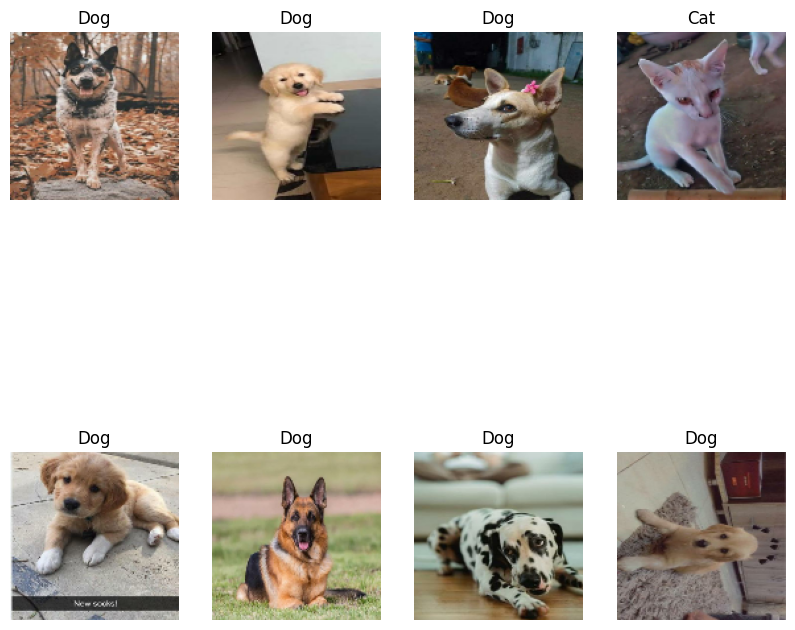

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(min(8, len(images))):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # Input image
    layers.Input(shape=(128, 128, 3)),

    # Data augmentation
    data_augmentation,

    # Normalize pixel values 0-255 to 0-1
    layers.Rescaling(1./255),

    # First Convolution Block
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Second Convolution Block
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Third Convolution Block
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps into one vector
    layers.Flatten(),

    # Fully Connected Layer
    layers.Dense(128, activation="relu"),

    # Reduce overfitting
    layers.Dropout(0.5),

    # Binary classification: Cat or Dog
    layers.Dense(1, activation="sigmoid")
])

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.4756 - loss: 0.8045 - val_accuracy: 0.4000 - val_loss: 0.6989
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 328ms/step - accuracy: 0.4634 - loss: 0.7039 - val_accuracy: 0.7000 - val_loss: 0.6917
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 459ms/step - accuracy: 0.4634 - loss: 0.6935 - val_accuracy: 0.7000 - val_loss: 0.6909
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 344ms/step - accuracy: 0.4634 - loss: 0.6929 - val_accuracy: 0.4500 - val_loss: 0.6923
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 321ms/step - accuracy: 0.5122 - loss: 0.6934 - val_accuracy: 0.6500 - val_loss: 0.6738
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 314ms/step - accuracy: 0.6341 - loss: 0.6817 - val_accuracy: 0.4000 - val_loss: 0.6820
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 562ms/step - accuracy: 0.5976 - loss: 0.6725 - val_accuracy: 0.8000 - val_loss: 0.6192
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 338ms/step - accuracy: 0.5732 - loss: 0.6594 - val_accuracy: 0.85

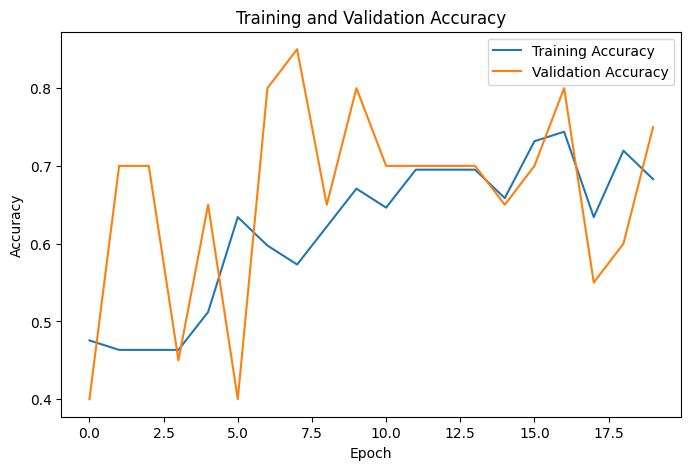

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.show()

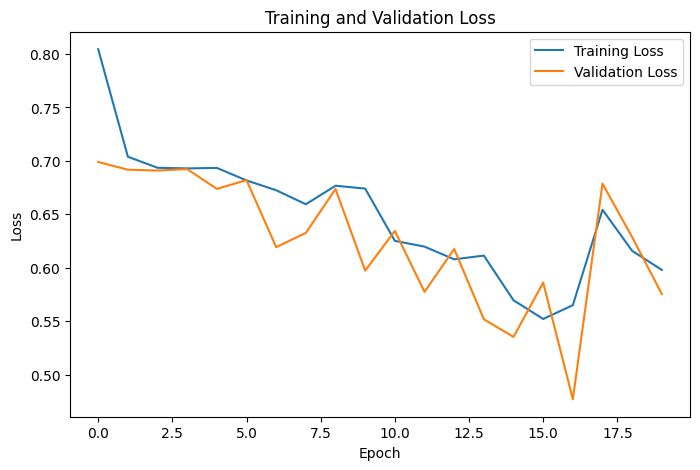

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.show()

In [ ]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.7500 - loss: 0.5754
Validation Loss: 0.5754083395004272
Validation Accuracy: 0.75


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    # Sigmoid probability ko Cat/Dog class mein convert
    predictions = (predictions >= 0.5).astype(int).flatten()

    y_true.extend(labels.numpy())
    y_pred.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Actual Labels:")
print(y_true)

print("\nPredicted Labels:")
print(y_pred)

Actual Labels:
[1 1 1 0 1 1 1 1 1 0 0 0 0 1 1 0 1 0 1 0]

Predicted Labels:
[1 0 1 0 0 1 0 1 1 1 1 0 0 1 1 0 1 0 1 0]


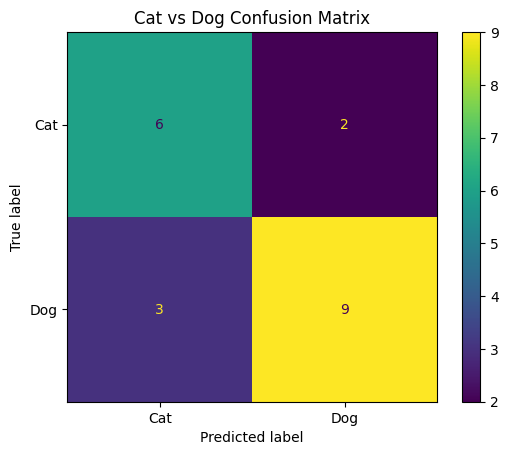

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat", "Dog"]
)

disp.plot()

plt.title("Cat vs Dog Confusion Matrix")
plt.show()

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Cat", "Dog"]
    )
)

              precision    recall  f1-score   support

         Cat       0.67      0.75      0.71         8
         Dog       0.82      0.75      0.78        12

    accuracy                           0.75        20
   macro avg       0.74      0.75      0.74        20
weighted avg       0.76      0.75      0.75        20



Prediction: Cat
Confidence: 50.57 %


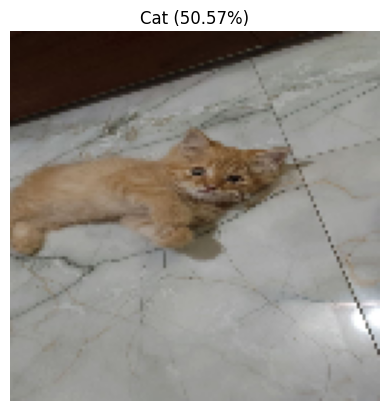

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

IMAGE_PATH = "/content/drive/MyDrive/Cat_Dog_ML_Dataset/Cat/cat10.jpg"

# Image load karo
img = load_img(
    IMAGE_PATH,
    target_size=(128, 128)
)

# Image ko array mein convert karo
img_array = img_to_array(img)

# Batch dimension add karo
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array, verbose=0)[0][0]

# Result
if prediction >= 0.5:
    predicted_class = "Dog"
    confidence = prediction * 100
else:
    predicted_class = "Cat"
    confidence = (1 - prediction) * 100

print("Prediction:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

# Image display
plt.imshow(img)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence * 100 / 100:.2f}%)")
plt.show()

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/cat_dog_cnn.keras"

model.save(MODEL_PATH)

print("Model saved successfully!")
print(MODEL_PATH)

Model saved successfully!
/content/drive/MyDrive/cat_dog_cnn.keras


Prediction: Cat
Confidence: 72.89 %
Raw prediction: 0.27111074
Class names: ['Cat', 'Dog']


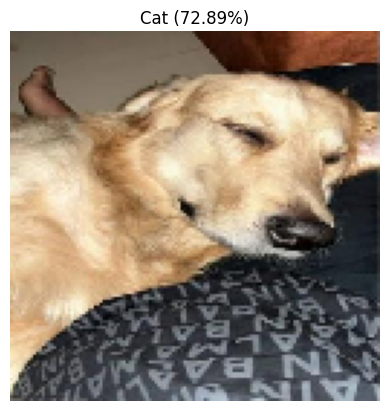

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

IMAGE_PATH = "/content/drive/MyDrive/Cat_Dog_ML_Dataset/Dog/dog_1.jpg"

# Image load karo
img = load_img(
    IMAGE_PATH,
    target_size=(128, 128)
)

# Image ko array mein convert karo
img_array = img_to_array(img)

# Batch dimension add karo
img_array = np.expand_dims(img_array, axis=0)

# Prediction
prediction = model.predict(img_array, verbose=0)[0][0]

# Result
if prediction >= 0.5:
    predicted_class = "Dog"
    confidence = prediction * 100
else:
    predicted_class = "Cat"
    confidence = (1 - prediction) * 100

print("Prediction:", predicted_class)
print("Confidence:", round(confidence, 2), "%")
print("Raw prediction:", prediction)
print("Class names:", class_names)

# Image display
plt.imshow(img)
plt.axis("off")
plt.title(f"{predicted_class} ({confidence * 100 / 100:.2f}%)")
plt.show()

In [ ]:
prediction = model.predict(img_array, verbose=0)[0][0]

print("Raw prediction:", prediction)
print("Class names:", class_names)

if prediction >= 0.5:
    predicted_class = "Dog"
    confidence = prediction * 100
else:
    predicted_class = "Cat"
    confidence = (1 - prediction) * 100

print("Prediction:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

Raw prediction: 0.27111074
Class names: ['Cat', 'Dog']
Prediction: Cat
Confidence: 72.89 %


In [ ]:
print("Training Accuracy:", history.history["accuracy"][-1])
print("Validation Accuracy:", history.history["val_accuracy"][-1])

Training Accuracy: 0.6829268336296082
Validation Accuracy: 0.75


In [ ]:
print("Raw prediction:", prediction)

Raw prediction: 0.27111074


In [ ]:
print("Raw prediction:", prediction)

if prediction >= 0.5:
    print("Model says: DOG")
else:
    print("Model says: CAT")

Raw prediction: 0.27111074
Model says: CAT


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 429ms/step - accuracy: 0.8049 - loss: 0.4271 - val_accuracy: 0.6000 - val_loss: 0.7016
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 294ms/step - accuracy: 0.7439 - loss: 0.4530 - val_accuracy: 0.7000 - val_loss: 0.4736
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 450ms/step - accuracy: 0.8171 - loss: 0.4500 - val_accuracy: 0.8000 - val_loss: 0.5013
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 376ms/step - accuracy: 0.7317 - loss: 0.4016 - val_accuracy: 0.8500 - val_loss: 0.4735
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 331ms/step - accuracy: 0.8293 - loss: 0.3767 - val_accuracy: 0.8000 - val_loss: 0.5128
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 471ms/step - accuracy: 0.8537 - loss: 0.3832 - val_accuracy: 0.8000 - val_loss: 0.4894
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 375ms/step - accuracy: 0.7927 - loss: 0.3930 - val_accuracy: 0.7500 - val_loss: 0.4508
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 467ms/step - accuracy: 0.8293 - loss: 0.4026 - val_accuracy: 0.

In [ ]:
print("Training Accuracy:", history.history["accuracy"][-1])
print("Validation Accuracy:", history.history["val_accuracy"][-1])

Training Accuracy: 0.8170731663703918
Validation Accuracy: 0.699999988079071


In [ ]:
import tensorflow as tf

DATASET_DIR = "/content/drive/MyDrive/Cat_Dog_ML_Dataset"

IMG_SIZE = (128, 128)
BATCH_SIZE = 8

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Classes:", train_ds.class_names)

Found 102 files belonging to 2 classes.
Using 82 files for training.
Found 102 files belonging to 2 classes.
Using 20 files for validation.
Classes: ['Cat', 'Dog']


In [ ]:
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15)
])

model = models.Sequential([

    layers.Input(shape=(128, 128, 3)),

    # Data augmentation
    data_augmentation,

    # Normalize pixels
    layers.Rescaling(1./255),

    # CNN Block 1
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # CNN Block 2
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # CNN Block 3
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # CNN Block 4
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    # Convert feature maps to vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Reduce overfitting
    layers.Dropout(0.5),

    # Cat/Dog
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 830,913 (3.17 MB)

 Trainable params: 830,913 (3.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,

)